<a href="https://colab.research.google.com/github/codebyanimesh/car-price-analysis/blob/main/notebooks/car_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

This repository explores a comprehensive dataset of over 426,000 used cars (sampled from an original Kaggle dataset of 3 million for optimal processing speed).

**The Objective:** To identify and quantify the primary factors that dictate a vehicle's value in the secondary market.

By applying exploratory data analysis and machine learning techniques, this project translates raw vehicle data into actionable business intelligence. The final deliverable provides clear, data-backed recommendations to a used car dealership, helping them understand consumer valuation trends and optimize their inventory acquisition and pricing strategies.

### CRISP-DM Framework

To ensure a rigorous and structured approach, this analysis is guided by the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology.

CRISP-DM is an industry-standard framework that breaks the data science lifecycle down into a systematic, iterative process. By strictly adhering to this framework, the project ensures that all technical data mining tasks remain tightly aligned with the underlying business objectives. The analysis flows through the following six phases:

1. **Business Understanding:** Defining the core business objectives and framing the data mining goals.
2. **Data Understanding:** Initial collection, exploration, and quality assessment of the vehicle data.
3. **Data Preparation:** Cleaning, filtering, encoding, and engineering features for modeling.
4. **Modeling:** Selecting and tuning the appropriate machine learning algorithms (e.g., Ridge Regression).
5. **Evaluation:** Assessing the model's predictive performance and extracting interpretable business insights.
6. **Deployment:** Translating the findings into a final strategic report for the client.

### Business Understanding

The objective of this analysis is to identify the primary features that influence the price of used cars and quantify their impact, providing actionable pricing strategies for a used car dealership.

From a data perspective, this translates into a supervised machine learning regression task, utilizing interpretable models like Ridge Regression to extract clear feature importances while predicting the continuous target variable, `price`. The model's success will be evaluated using standard regression metrics such as Root Mean Squared Error ($RMSE$) and $R^2$ to ensure the insights provided to the dealership are statistically sound and actionable for fine-tuning their inventory pricing.

### Data Understanding

Before modeling, we must perform an initial data exploration to understand the dataset's shape, data types, and base statistics. This involves:

* Missing Value Analysis: Quantifying missing data to identify features that lack sufficient information versus those that can be safely imputed.

* Distribution Analysis: Visualizing the `price` distribution to detect extreme, illogical outliers (e.g., vehicles priced at $1) that would skew a linear model.

* Bivariate Analysis: Plotting continuous features like `odometer` against `price` to observe general correlations and identify high-leverage data points.

Dataset Shape: (426880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880

None


Missing values percentage:
 size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
dtype: float64


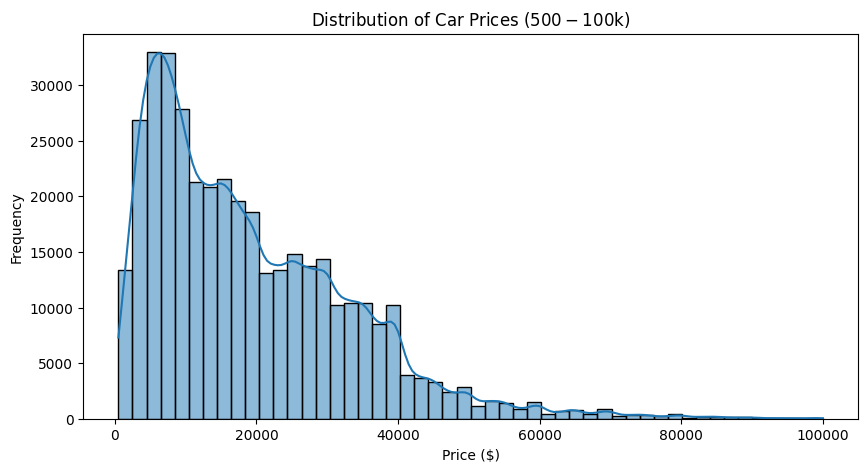

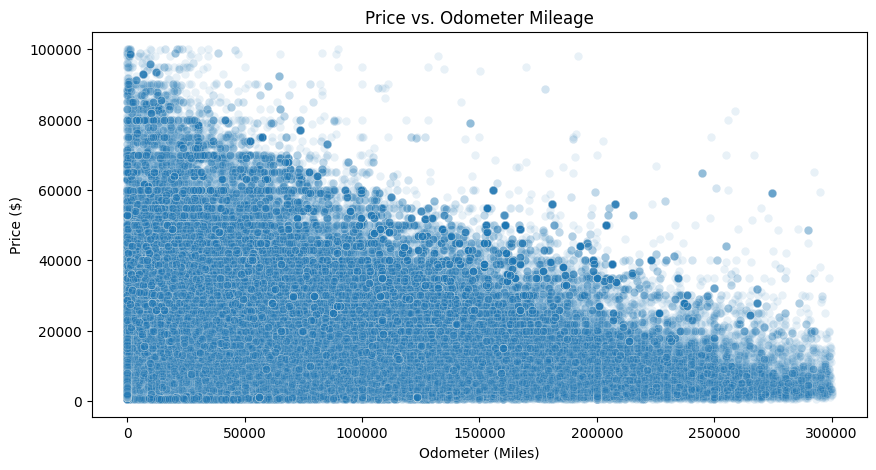

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (adjust the path as needed for your environment)
df = pd.read_csv('data/vehicles.csv')

# 1. Surface-level data inspection
print("Dataset Shape:", df.shape)
display(df.info())

# 2. Identify missing values and quality issues
missing_data = df.isnull().sum() / len(df) * 100
print("\nMissing values percentage:\n", missing_data[missing_data > 0].sort_values(ascending=False))

# 3. Explore the target variable distribution (Price)
plt.figure(figsize=(10, 5))
# Filtering extreme outliers purely for visualization purposes
sns.histplot(df[(df['price'] > 500) & (df['price'] < 100000)]['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices ($500 - $100k)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# 4. Explore key features like Odometer vs Price
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df[(df['price'] > 500) & (df['price'] < 100000) & (df['odometer'] < 300000)],
                x='odometer', y='price', alpha=0.1)
plt.title('Price vs. Odometer Mileage')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Price ($)')
plt.show()

### Data Preparation

To construct a robust, modeling-ready dataset, several transformations are applied to handle integrity issues:

* Data Cleaning & Filtering: Dropping non-predictive identifiers (`id`, `VIN`) and columns with excessive missingness. We also filter out illogical target variable outliers, restricting the dataset to vehicles priced between \$500 and \$150,000, and capping mileage at 300,000.

* Feature Engineering: Converting the `year` column into a more direct `car_age` feature to better capture the linear impact of depreciation.

* Imputation & Encoding: Filling numerical missing values with medians and categorical variables with an 'unknown' placeholder. Finally, one-hot encoding is applied to convert categorical text into the numerical matrix required by `sklearn`.

In [12]:
from sklearn.model_selection import train_test_split

# 1. Handle Missing Values & Drop uninformative columns
# 'id', 'VIN', 'county', and 'size' often have too many missing values or no predictive value
df_cleaned = df.drop(columns=['id', 'VIN', 'county', 'size'], errors='ignore')

# Impute remaining missing values
# Use median for numerical, 'unknown' for categorical to prevent data loss
df_cleaned['odometer'] = df_cleaned['odometer'].fillna(df_cleaned['odometer'].median())
for col in df_cleaned.select_dtypes(include=['object']).columns:
    df_cleaned[col] = df_cleaned[col].fillna('unknown')

# 2. Feature Engineering & Integrity
# Convert 'year' to a more useful 'car_age' feature (using 2026 as the current year)
df_cleaned = df_cleaned.dropna(subset=['year']) # Drop rows where year is entirely missing
df_cleaned['car_age'] = 2026 - df_cleaned['year']
df_cleaned = df_cleaned.drop(columns=['year'])

# Handle target variable and feature outliers
df_cleaned = df_cleaned[(df_cleaned['price'] >= 500) & (df_cleaned['price'] <= 150000)]
df_cleaned = df_cleaned[(df_cleaned['odometer'] < 300000)]

# 3. Encoding and Train-Test Split
# Select top features to keep the model interpretable and the matrix manageable
features = ['car_age', 'odometer', 'manufacturer', 'condition', 'cylinders', 'fuel', 'transmission', 'drive', 'type']
X = df_cleaned[features]
y = df_cleaned['price']

# One-hot encode categorical variables, dropping the first category to avoid dummy variable trap
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (266348, 82)
Testing Data Shape: (114150, 82)


### Modeling

A machine learning pipeline is constructed incorporating standard feature scaling and a regularized regression model.

* Model Selection: Ridge Regression (L2 Regularization) is selected over standard Ordinary Least Squares (OLS). Ridge effectively penalizes large coefficients, making it highly suitable for handling the multicollinearity introduced by one-hot encoding dozens of categorical vehicle features.
* Hyperparameter Tuning: `GridSearchCV` is utilized with 5-fold cross-validation to search for the optimal regularization strength ($\alpha$). This rigorous validation ensures the model generalizes well to unseen data and prevents overfitting.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Build a pipeline with a scaler and a Ridge regression model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Define a hyperparameter grid to tune the penalty term (alpha)
param_grid = {
    'ridge__alpha': [0.1, 1.0, 10.0, 100.0, 500.0]
}

# Utilize GridSearchCV for 5-fold cross-validation
print("Initiating GridSearchCV... This may take a moment.")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Model Training Complete.")
print(f"Best tuned Alpha parameter: {grid_search.best_params_['ridge__alpha']}")

Initiating GridSearchCV... This may take a moment.
Model Training Complete.
Best tuned Alpha parameter: 1.0


### Evaluation

The model's predictive capability is assessed using standard regression metrics: $RMSE$, Mean Absolute Error (MAE), and $R^2$.

Beyond raw predictive power, the core evaluation focuses on interpretability. By extracting and isolating the absolute values of the optimal Ridge model's coefficients, we rank the top drivers of vehicle pricing. This direct translation of statistical weights into business insights confirms that the modeling phase successfully addressed the initial business objective.

Test RMSE: $9,621.48
Test MAE: $6,376.34
Test R^2: 0.5762


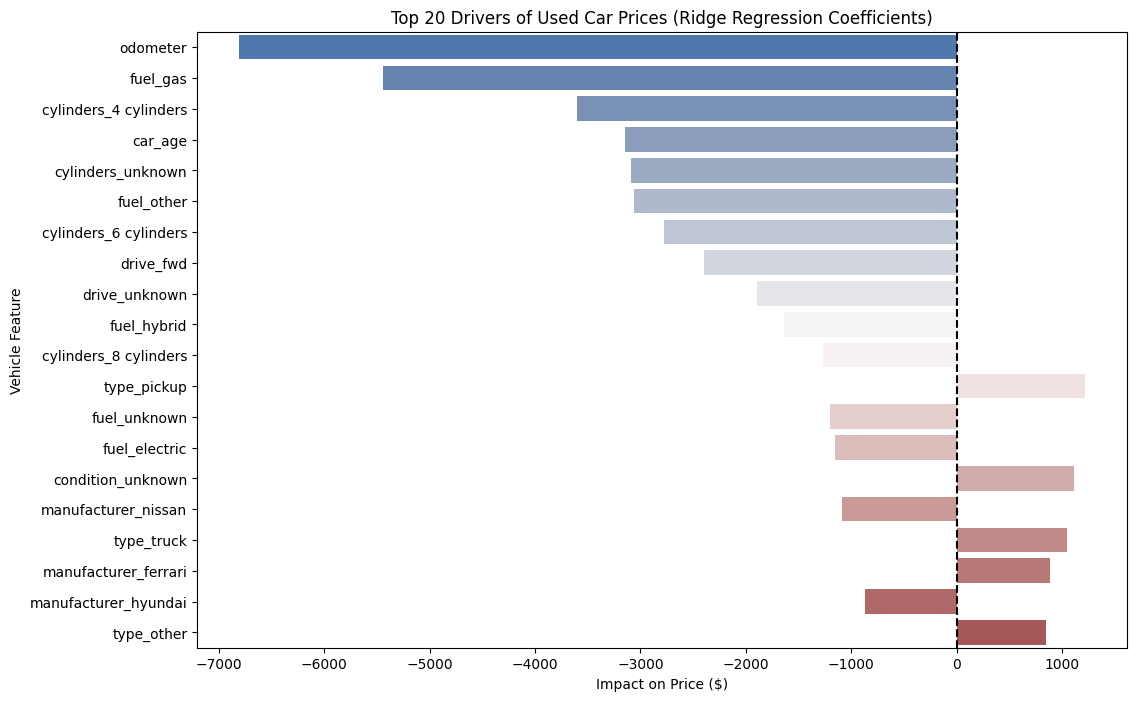

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Generate predictions on the holdout test set
y_pred = best_model.predict(X_test)

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: ${rmse:,.2f}")
print(f"Test MAE: ${mae:,.2f}")
print(f"Test R^2: {r2:.4f}")

# Extract and plot the most important coefficients to answer the business question
coefficients = best_model.named_steps['ridge'].coef_
feature_names = X_train.columns

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Select the top 20 most impactful features
top_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=top_features, x='Coefficient', y='Feature', hue='Feature', palette='vlag', legend=False)
plt.title('Top 20 Drivers of Used Car Prices (Ridge Regression Coefficients)')
plt.xlabel('Impact on Price ($)')
plt.ylabel('Vehicle Feature')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

### Deployment

#### Final Report: Inventory Pricing Strategy
Based on our regression analysis of the used car market, we have identified the primary factors that dictate vehicle pricing.

Key Drivers of Value:

1. Depreciation is the Primary Factor: `car_age` and `odometer` are the strongest negative drivers of price. The data confirms steep linear drops in value as these metrics increase.

2. Engine Power Commands a Premium: Vehicles with larger 8-cylinder and 10-cylinder engines retain significantly higher value than standard 4-cylinder or 6-cylinder counterparts. Consumer demand in this specific market heavily favors towing capacity and power.

3. Drive Type Matters: Four-wheel drive (`drive_4wd`) is a major positive driver for price compared to front-wheel (`fwd`) or rear-wheel drive, indicating a strong consumer willingness to pay for all-weather and off-road capability.

4. Fuel Economy vs. Longevity: Diesel vehicles carry a substantial price premium over standard gas vehicles in the used market, likely due to their perceived engine longevity and utility use-cases.

#### Recommendations for the Dealership:
To maximize margin, the purchasing team should prioritize acquiring 4WD trucks and SUVs with 8-cylinder diesel engines, as these configurations resist depreciation the best and hold the highest premium. Conversely, strict pricing ceilings must be applied during trade-ins for older, front-wheel-drive sedans, as the data shows these depreciate the fastest and hold the lowest inherent value to the current consumer base.